# 🔬 Wyckoff Pattern — Deep Learning Research
### CRISP-DM Framework | Deep Learning (LSTM + 1D-CNN)

---
**CRISP-DM Phases:**
1. **Business Understanding** — วัตถุประสงค์งานวิจัย Wyckoff + DL
2. **Data Understanding** — สำรวจและทำความเข้าใจข้อมูล
3. **Data Preparation** — Feature Engineering + Sequence Building
4. **Modeling** — Deep Learning: LSTM, Bi-LSTM, 1D-CNN, CNN-LSTM
5. **Evaluation** — Walk-Forward, ROC, Win Rate, Backtest
6. **Deployment** — Research Dashboard

---
**Wyckoff Events:**
- **Accumulation**: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU
- **Distribution**: PSY, BC, AR_D, ST_D, UT, UTAD, SOW, LPSY

---
## 📋 Phase 1: Business Understanding

In [26]:
# ===== CRISP-DM Phase 1: Business Understanding =====
print("="*70)
print("   CRISP-DM Phase 1: BUSINESS UNDERSTANDING")
print("="*70)

import pandas as pd

business_obj = {
    'วัตถุประสงค์': [
        '1. ตรวจจับ Wyckoff Event ด้วย Rule-Based Logic',
        '2. สร้าง Deep Learning Model จำแนก Event Label (Acc / Dist)',
        '3. ทำนายทิศทางราคาหลังเกิด Event ล่วงหน้า 10 วัน ด้วย DL',
        '4. วัด Win Rate ของสัญญาณแต่ละ Event',
        '5. Backtest เพื่อประเมินมูลค่าสัญญาณ',
    ],
    'เกณฑ์ความสำเร็จ': [
        'Classification Accuracy > 70%',
        'AUC-ROC > 0.60',
        'Win Rate ของ LPS/SOS > 55%',
        'DL Strategy Sharpe Ratio > 0.5',
    ],
    'โมเดล Deep Learning': [
        'LSTM (Long Short-Term Memory)',
        'Bidirectional LSTM',
        'Conv1D (1D-Convolutional Network)',
        'CNN-LSTM (Hybrid)',
    ],
}

for key, items in business_obj.items():
    print(f'\n📌 {key}:')
    for item in items:
        print(f'   {item}')
print("\n" + "="*70)

   CRISP-DM Phase 1: BUSINESS UNDERSTANDING

📌 วัตถุประสงค์:
   1. ตรวจจับ Wyckoff Event ด้วย Rule-Based Logic
   2. สร้าง Deep Learning Model จำแนก Event Label (Acc / Dist)
   3. ทำนายทิศทางราคาหลังเกิด Event ล่วงหน้า 10 วัน ด้วย DL
   4. วัด Win Rate ของสัญญาณแต่ละ Event
   5. Backtest เพื่อประเมินมูลค่าสัญญาณ

📌 เกณฑ์ความสำเร็จ:
   Classification Accuracy > 70%
   AUC-ROC > 0.60
   Win Rate ของ LPS/SOS > 55%
   DL Strategy Sharpe Ratio > 0.5

📌 โมเดล Deep Learning:
   LSTM (Long Short-Term Memory)
   Bidirectional LSTM
   Conv1D (1D-Convolutional Network)
   CNN-LSTM (Hybrid)



---
## ⚙️ Phase 2: Data Understanding — Setup & Import

In [27]:
# ===== IMPORTS (Deep Learning Mode) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)
plt.style.use('dark_background')
COLORS = {
    'accent': '#00D4FF', 'green': '#00FF88', 'red': '#FF4444',
    'yellow': '#FFD700', 'purple': '#BB86FC', 'orange': '#FF8C00'
}

# --- Deep Learning (TensorFlow / Keras) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Input, Flatten, TimeDistributed
)

# --- Sklearn (สำหรับ preprocessing & evaluation เท่านั้น) ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, f1_score
)

# --- Optional: SMOTE ---
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
    print('✅ imbalanced-learn (SMOTE) พร้อมใช้งาน')
except ImportError:
    HAS_SMOTE = False
    print('⚠️  imbalanced-learn ไม่ได้ติดตั้ง — ข้าม SMOTE')

print(f'\n✅ TensorFlow {tf.__version__} | Keras {keras.__version__}')
print('✅ Import สำเร็จ — Deep Learning Mode')
GPU = tf.config.list_physical_devices('GPU')
print(f'   GPU: {GPU if GPU else "ไม่พบ GPU — ใช้ CPU"}')

✅ imbalanced-learn (SMOTE) พร้อมใช้งาน

✅ TensorFlow 2.20.0 | Keras 3.13.1
✅ Import สำเร็จ — Deep Learning Mode
   GPU: ไม่พบ GPU — ใช้ CPU


In [28]:
# ===== โหลดข้อมูล =====
print("="*70)
print("   CRISP-DM Phase 2: DATA UNDERSTANDING — โหลดข้อมูล")
print("="*70)

file_path = "/Users/hilmanyusoh/Desktop/stock_pattern/data/ข้อมูลย้อนหลังของ ดัชนี SET 100.csv"
df = pd.read_csv(file_path, thousands=',', decimal='.')
df.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

def convert_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.upper()
        if 'B' in vol_str: return float(vol_str.replace('B', '')) * 1e9
        if 'M' in vol_str: return float(vol_str.replace('M', '')) * 1e6
        if 'K' in vol_str: return float(vol_str.replace('K', '')) * 1e3
    return float(vol_str)

df['Volume'] = df['Volume'].apply(convert_volume)
df = df.dropna()
df = df[df['Volume'] > 0].reset_index(drop=True)

print(f'\n✅ โหลดข้อมูลสำเร็จ')
print(f'   จำนวนแถว : {len(df):,}')
print(f'   ช่วงเวลา  : {df["Date"].min().date()} ถึง {df["Date"].max().date()}')
print(f'   จำนวนปี  : {(df["Date"].max() - df["Date"].min()).days / 365:.1f} ปี')

   CRISP-DM Phase 2: DATA UNDERSTANDING — โหลดข้อมูล

✅ โหลดข้อมูลสำเร็จ
   จำนวนแถว : 3,554
   ช่วงเวลา  : 2011-08-16 ถึง 2026-03-13
   จำนวนปี  : 14.6 ปี


In [29]:
# ===== ตาราง: ข้อมูลเบื้องต้น =====
print('📊 ตาราง: ข้อมูล 5 แถวแรก')
display(df.head())

print('\n📊 ตาราง: สถิติพื้นฐาน')
display(df[['Close','Open','High','Low','Volume']].describe().round(2))

print('\n📊 ตาราง: Missing Values')
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Pct (%)': (missing.values / len(df) * 100).round(2)
})
display(missing_df)

📊 ตาราง: ข้อมูล 5 แถวแรก


,Date,Close,Open,High,Low,Volume,Change_Pct
0,2011-08-16,1632.9000,1656.4500,1657.0000,1632.9000,1900000.0000,-0.98%
1,2011-08-17,1659.8400,1647.0200,1662.9300,1645.0300,2030000.0000,1.65%
2,2011-08-18,1654.8600,1669.8800,1676.6100,1653.0100,1960000.0000,-0.30%
3,2011-08-19,1621.0900,1627.6900,1638.6000,1616.0600,2320000.0000,-2.04%
4,2011-08-22,1619.7200,1620.2000,1621.1300,1592.8100,1890000.0000,-0.08%



📊 ตาราง: สถิติพื้นฐาน


,Close,Open,High,Low,Volume
count,3554.0000,3554.0000,3554.0000,3554.0000,3554.0000
mean,2096.2100,2097.6000,2108.6300,2084.2300,2326156216.6400
std,256.6800,257.2400,256.2500,257.3600,1095946391.5600
min,1284.8100,1297.0000,1315.9100,1266.0200,630350.0000
25%,1911.2900,1911.9000,1922.2800,1898.9800,1710000000.0000
50%,2127.8600,2130.2000,2142.2900,2115.8500,2160000000.0000
75%,2258.7400,2262.0100,2271.2700,2249.4600,2770000000.0000
max,2677.3900,2691.2300,2711.9600,2674.3100,16850000000.0000



📊 ตาราง: Missing Values


,Column,Missing,Pct (%)
0,Date,0,0.0000
1,Close,0,0.0000
2,Open,0,0.0000
3,High,0,0.0000
4,Low,0,0.0000
5,Volume,0,0.0000
6,Change_Pct,0,0.0000


---
## 🔧 Phase 3: Data Preparation — Feature Engineering

In [31]:
# ===== CRISP-DM Phase 3: Feature Engineering =====
print("="*70)
print("   CRISP-DM Phase 3: DATA PREPARATION — Feature Engineering")
print("="*70)

# --- Wyckoff Core Features ---
df['Spread']       = df['High'] - df['Low']
df['Close_Pos']    = (df['Close'] - df['Low']) / (df['Spread'] + 1e-6)
df['Lower_Shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)
df['Vol_MA20']     = df['Volume'].rolling(20).mean()
df['Rel_Vol']      = df['Volume'] / (df['Vol_MA20'] + 1e-6)
df['Spread_MA20']  = df['Spread'].rolling(20).mean()
df['Rel_Spread']   = df['Spread'] / (df['Spread_MA20'] + 1e-6)
df['Price_Trend']  = df['Close'].diff(5)

# --- Trading Range ---
window_tr = 50
df['Support_TR']    = df['Low'].rolling(window_tr).min().shift(1)
df['Resistance_TR'] = df['High'].rolling(window_tr).max().shift(1)
df['Dist_from_Sup'] = (df['Low'] - df['Support_TR']) / (df['Support_TR'] + 1e-6)
df['Dist_from_Res'] = (df['High'] - df['Resistance_TR']) / (df['Resistance_TR'] + 1e-6)

# --- Momentum & Trend ---
df['Return_1d']     = df['Close'].pct_change(1)
df['Return_5d']     = df['Close'].pct_change(5)
df['Return_10d']    = df['Close'].pct_change(10)
df['MA10']          = df['Close'].rolling(10).mean()
df['MA20']          = df['Close'].rolling(20).mean()
df['MA50']          = df['Close'].rolling(50).mean()
df['Price_vs_MA10'] = df['Close'] / (df['MA10'] + 1e-6) - 1
df['Price_vs_MA20'] = df['Close'] / (df['MA20'] + 1e-6) - 1
df['Price_vs_MA50'] = df['Close'] / (df['MA50'] + 1e-6) - 1
df['MA10_slope']    = df['MA10'].diff(3) / (df['MA10'].shift(3) + 1e-6)
df['MA20_slope']    = df['MA20'].diff(3) / (df['MA20'].shift(3) + 1e-6)

# --- RSI ---
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI']       = 100 - (100 / (1 + gain / (loss + 1e-6)))
df['RSI_slope'] = df['RSI'].diff(3)

# --- Bollinger Bands ---
bb_mid = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
df['BB_Width']    = (2 * bb_std) / (bb_mid + 1e-6)
df['BB_Position'] = (df['Close'] - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-6)

# --- MACD ---
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# --- Volume ---
df['Vol_MA5']   = df['Volume'].rolling(5).mean()
df['Vol_Spike'] = df['Volume'] / (df['Vol_MA5'] + 1e-6)
df['Vol_trend'] = df['Volume'].pct_change(5)

# --- Candle Structure ---
df['Body_Size']    = abs(df['Close'] - df['Open']) / (df['Spread'] + 1e-6)
df['Is_Bullish']   = (df['Close'] > df['Open']).astype(int)
df['Shadow_Ratio'] = df['Lower_Shadow'] / (df['Upper_Shadow'] + 1e-6)

# --- Trading Range Position ---
tr_range = df['Resistance_TR'] - df['Support_TR'] + 1e-6
df['TR_Position'] = (df['Close'] - df['Support_TR']) / tr_range

# --- Volatility ---
df['ATR14']      = df['Spread'].rolling(14).mean()
df['ATR_ratio']  = df['Spread'] / (df['ATR14'] + 1e-6)
df['Volatility'] = df['Return_1d'].rolling(20).std()

# --- Feature list ---
DL_FEATURES = [
    'Spread','Close_Pos','Lower_Shadow','Upper_Shadow',
    'Rel_Vol','Rel_Spread','Price_Trend',
    'Dist_from_Sup','Dist_from_Res','TR_Position',
    'Return_1d','Return_5d','Return_10d',
    'Price_vs_MA10','Price_vs_MA20','Price_vs_MA50',
    'MA10_slope','MA20_slope',
    'RSI','RSI_slope','BB_Width','BB_Position','MACD_Hist',
    'Vol_Spike','Vol_trend',
    'Body_Size','Is_Bullish','Shadow_Ratio',
    'ATR_ratio','Volatility',
]

print(f'✅ Feature Engineering เสร็จสิ้น | จำนวน Features: {len(DL_FEATURES)}')

   CRISP-DM Phase 3: DATA PREPARATION — Feature Engineering
✅ Feature Engineering เสร็จสิ้น | จำนวน Features: 30


📊 ตาราง: Feature Groups


,Group,Features
0,Wyckoff Core,"Spread, Close_Pos, Lower_Shadow, Upper_Shadow,..."
1,Trading Range,"Dist_from_Sup, Dist_from_Res, TR_Position"
2,Momentum,"Return_1d, Return_5d, Return_10d, Price_vs_MA1..."
3,Trend,"MA10_slope, MA20_slope"
4,Technical,"RSI, RSI_slope, BB_Width, BB_Position, MACD_Hist"
5,Volume,"Vol_Spike, Vol_trend"
6,Candle,"Body_Size, Is_Bullish, Shadow_Ratio"
7,Volatility,"ATR_ratio, Volatility"


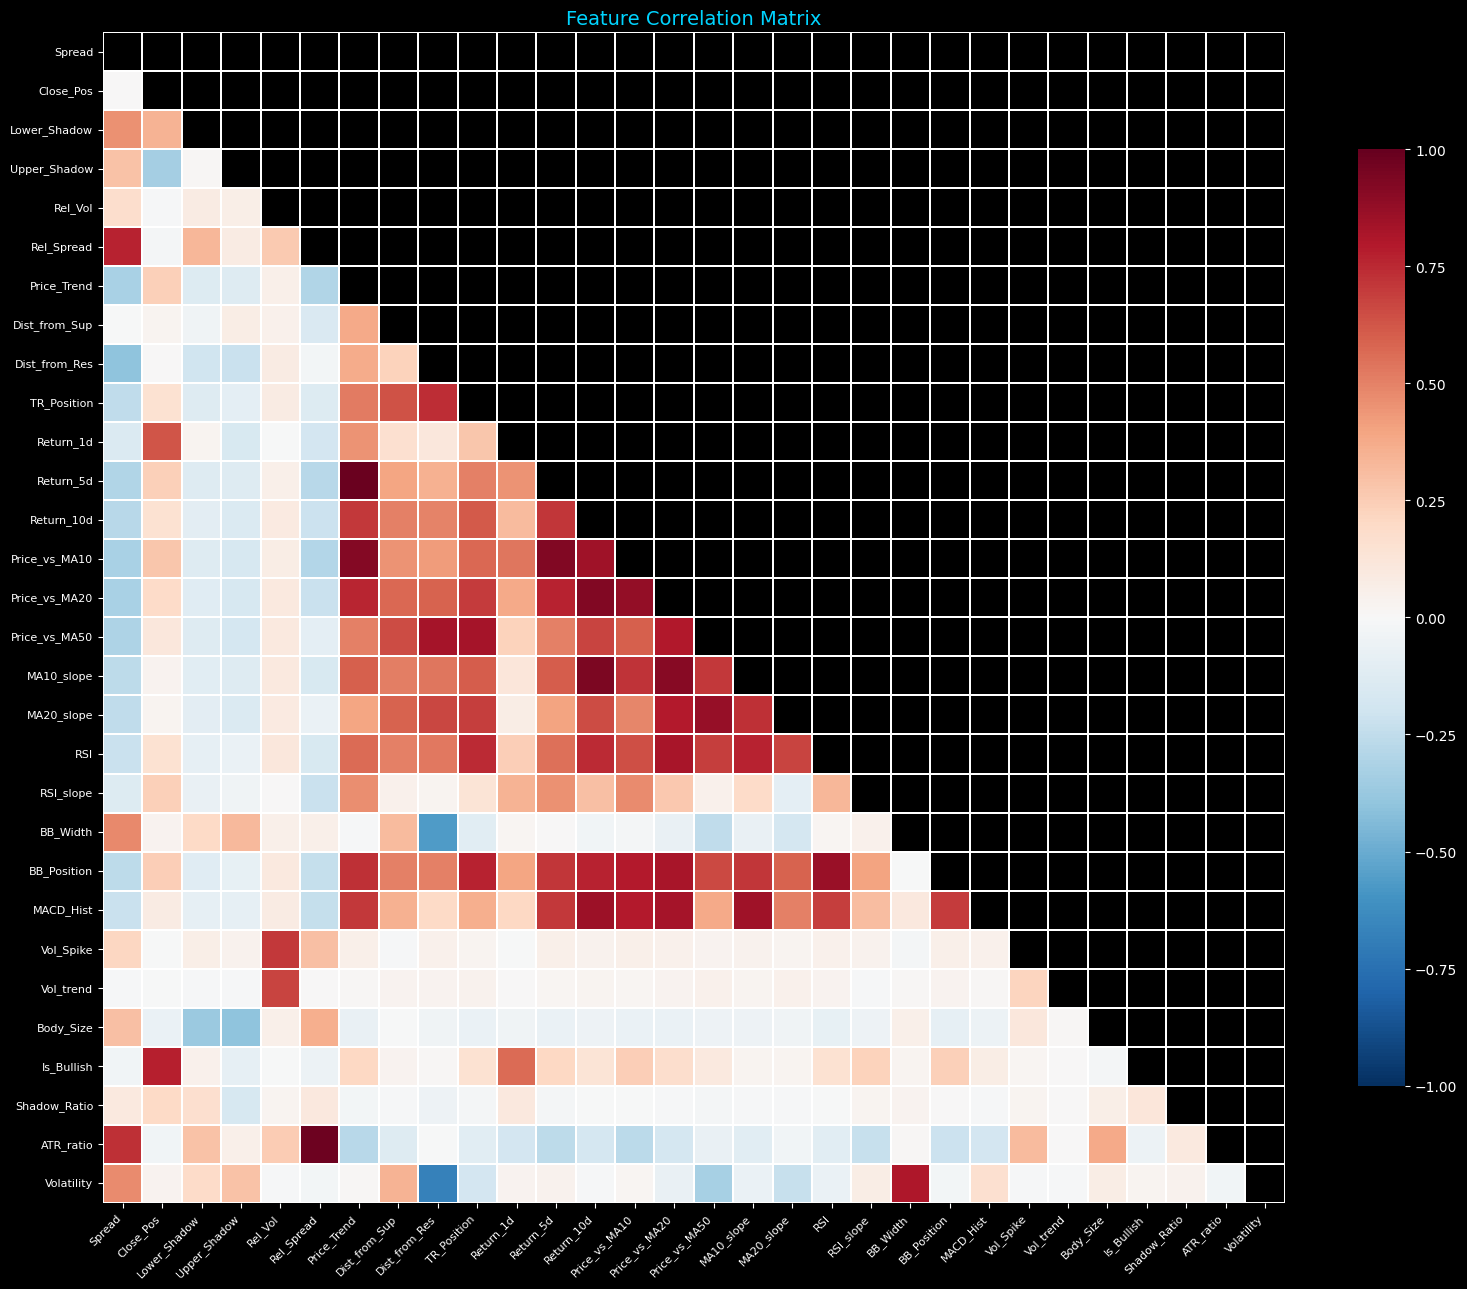

In [32]:
# ===== ตาราง: Feature Summary + Correlation =====
print('📊 ตาราง: Feature Groups')
feature_groups = {
    'Wyckoff Core':   ['Spread','Close_Pos','Lower_Shadow','Upper_Shadow','Rel_Vol','Rel_Spread','Price_Trend'],
    'Trading Range':  ['Dist_from_Sup','Dist_from_Res','TR_Position'],
    'Momentum':       ['Return_1d','Return_5d','Return_10d','Price_vs_MA10','Price_vs_MA20','Price_vs_MA50'],
    'Trend':          ['MA10_slope','MA20_slope'],
    'Technical':      ['RSI','RSI_slope','BB_Width','BB_Position','MACD_Hist'],
    'Volume':         ['Vol_Spike','Vol_trend'],
    'Candle':         ['Body_Size','Is_Bullish','Shadow_Ratio'],
    'Volatility':     ['ATR_ratio','Volatility'],
}
fg_df = pd.DataFrame(
    [(g, ', '.join(fs)) for g, fs in feature_groups.items()],
    columns=['Group', 'Features']
)
display(fg_df)

# Correlation heatmap
df_clean = df.dropna(subset=DL_FEATURES)
corr = df_clean[DL_FEATURES].corr()
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, color=COLORS['accent'])
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

---
## 🏷️ Wyckoff Event Detection — Rule-Based

In [33]:
# ===== Wyckoff Event Detection (Rule-Based) =====
print("="*70)
print("   WYCKOFF EVENT DETECTION")
print("   Accumulation: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU")
print("   Distribution: PSY, BC, AR_D, ST_D, UT, UTAD, SOW, LPSY")
print("="*70)

THRESHOLD_SC_VOL     = 1.3
THRESHOLD_SOS_VOL    = 1.2
THRESHOLD_SPRING_POS = 0.5
THRESHOLD_LPS_VOL    = 0.85

df['Wyckoff_Event']     = ""
df['Wyckoff_Phase']     = ""
df['Wyckoff_Phase_Num'] = 0

last_sc_idx = -1
has_phase_a = False

ACCUM_EVENTS = ['PS','SC','AR','ST','SPRING','TEST','LPS','SOS','BU']
DIST_EVENTS  = ['PSY','BC','AR_D','ST_D','UT','UTAD','SOW','LPSY']

# ---- ACCUMULATION ----
for i in range(window_tr + 1, len(df)):
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    low       = df.loc[i, 'Low']
    high      = df.loc[i, 'High']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']
    dist_sup  = df.loc[i, 'Dist_from_Sup']

    if rel_vol > THRESHOLD_SC_VOL and trend < 0:
        if close_pos > 0.20:
            df.at[i,'Wyckoff_Event'] = "SC"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
            df.at[i,'Wyckoff_Phase_Num'] = 1; last_sc_idx = i; has_phase_a = True
        else:
            df.at[i,'Wyckoff_Event'] = "PS"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
            df.at[i,'Wyckoff_Phase_Num'] = 1
    elif has_phase_a and last_sc_idx != -1 and i < last_sc_idx + 20:
        if close > df.loc[i-1,'Close'] and high == df.loc[last_sc_idx+1:i+1,'High'].max():
            if "AR" not in df.loc[last_sc_idx:i,'Wyckoff_Event'].values:
                df.at[i,'Wyckoff_Event'] = "AR"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
                df.at[i,'Wyckoff_Phase_Num'] = 1
        elif low <= (sup * 1.03) and rel_vol < THRESHOLD_SC_VOL:
            if df.loc[i,'Wyckoff_Event'] == "":
                df.at[i,'Wyckoff_Event'] = "ST"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
                df.at[i,'Wyckoff_Phase_Num'] = 2
    elif has_phase_a and low < sup:
        if close_pos > THRESHOLD_SPRING_POS:
            df.at[i,'Wyckoff_Event'] = "SPRING"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
            df.at[i,'Wyckoff_Phase_Num'] = 3
        else:
            df.at[i,'Wyckoff_Event'] = "ST"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
            df.at[i,'Wyckoff_Phase_Num'] = 2
    elif has_phase_a and rel_vol < 0.8 and abs(dist_sup) < 0.02:
        if "SPRING" in df.loc[i-30:i,'Wyckoff_Event'].values:
            df.at[i,'Wyckoff_Event'] = "TEST"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
            df.at[i,'Wyckoff_Phase_Num'] = 3
    elif has_phase_a and close > res and rel_vol > THRESHOLD_SOS_VOL:
        df.at[i,'Wyckoff_Event'] = "SOS"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
        df.at[i,'Wyckoff_Phase_Num'] = 4
    elif has_phase_a and "SOS" in df.loc[i-15:i,'Wyckoff_Event'].values:
        if low >= res * 0.97 and close <= res * 1.05 and close_pos > 0.4:
            if "BU" not in df.loc[i-10:i,'Wyckoff_Event'].values:
                df.at[i,'Wyckoff_Event'] = "BU"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
                df.at[i,'Wyckoff_Phase_Num'] = 4
    elif has_phase_a and trend > 0 and close_pos > 0.6:
        is_higher_low = low > df.loc[i-15:i,'Low'].min()
        is_low_vol    = rel_vol < THRESHOLD_LPS_VOL
        is_upper_zone = close > (sup + (res - sup) * 0.6)
        if is_higher_low and is_low_vol and is_upper_zone:
            if "LPS" not in df.loc[i-10:i,'Wyckoff_Event'].values:
                df.at[i,'Wyckoff_Event'] = "LPS"; df.at[i,'Wyckoff_Phase'] = "Accumulation"
                df.at[i,'Wyckoff_Phase_Num'] = 4

# ---- DISTRIBUTION ----
THRESHOLD_BC_VOL   = 1.3
THRESHOLD_SOW_VOL  = 1.2
THRESHOLD_LPSY_VOL = 0.85
last_bc_idx = -1
has_dist_phase_a = False

for i in range(10, len(df)):
    if df.loc[i,'Wyckoff_Event'] != "": continue
    rel_vol   = df.loc[i,'Rel_Vol']
    close_pos = df.loc[i,'Close_Pos']
    trend     = df.loc[i,'Price_Trend']
    high      = df.loc[i,'High']
    low       = df.loc[i,'Low']
    close     = df.loc[i,'Close']
    sup       = df.loc[i,'Support_TR']
    res       = df.loc[i,'Resistance_TR']

    if rel_vol > THRESHOLD_BC_VOL and trend > 0:
        if close_pos < 0.80:
            df.at[i,'Wyckoff_Event'] = "BC"; df.at[i,'Wyckoff_Phase'] = "Distribution"
            df.at[i,'Wyckoff_Phase_Num'] = 1; last_bc_idx = i; has_dist_phase_a = True
        else:
            df.at[i,'Wyckoff_Event'] = "PSY"; df.at[i,'Wyckoff_Phase'] = "Distribution"
            df.at[i,'Wyckoff_Phase_Num'] = 1
    elif has_dist_phase_a and last_bc_idx != -1 and i < last_bc_idx + 20:
        if low == df.loc[last_bc_idx+1:i+1,'Low'].min() and close < df.loc[i-1,'Close']:
            if "AR_D" not in df.loc[last_bc_idx:i,'Wyckoff_Event'].values:
                df.at[i,'Wyckoff_Event'] = "AR_D"; df.at[i,'Wyckoff_Phase'] = "Distribution"
                df.at[i,'Wyckoff_Phase_Num'] = 1
        elif high >= (res * 0.97) and rel_vol < THRESHOLD_BC_VOL:
            if df.loc[i,'Wyckoff_Event'] == "":
                df.at[i,'Wyckoff_Event'] = "ST_D"; df.at[i,'Wyckoff_Phase'] = "Distribution"
                df.at[i,'Wyckoff_Phase_Num'] = 2
    elif has_dist_phase_a and high > res:
        if close_pos < 0.4:
            df.at[i,'Wyckoff_Event'] = "UTAD" if i > last_bc_idx + 20 else "UT"
            df.at[i,'Wyckoff_Phase'] = "Distribution"; df.at[i,'Wyckoff_Phase_Num'] = 3
    elif has_dist_phase_a and close < sup and rel_vol > THRESHOLD_SOW_VOL:
        df.at[i,'Wyckoff_Event'] = "SOW"; df.at[i,'Wyckoff_Phase'] = "Distribution"
        df.at[i,'Wyckoff_Phase_Num'] = 4
    elif has_dist_phase_a and trend < 0 and close_pos < 0.4:
        is_lower_high = high < df.loc[i-15:i,'High'].max()
        is_low_vol    = rel_vol < THRESHOLD_LPSY_VOL
        is_lower_zone = close < (sup + (res - sup) * 0.4)
        if is_lower_high and is_low_vol and is_lower_zone:
            if "LPSY" not in df.loc[i-10:i,'Wyckoff_Event'].values:
                df.at[i,'Wyckoff_Event'] = "LPSY"; df.at[i,'Wyckoff_Phase'] = "Distribution"
                df.at[i,'Wyckoff_Phase_Num'] = 4

print(f'\n✅ Wyckoff Event Detection เสร็จสิ้น')
print(f'   Events: {(df["Wyckoff_Event"] != "").sum():,} / {len(df):,} แถว '
      f'({(df["Wyckoff_Event"] != "").mean()*100:.1f}%)')

   WYCKOFF EVENT DETECTION
   Accumulation: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU
   Distribution: PSY, BC, AR_D, ST_D, UT, UTAD, SOW, LPSY

✅ Wyckoff Event Detection เสร็จสิ้น
   Events: 2,098 / 3,554 แถว (59.0%)


In [34]:
# ===== ตาราง: Accumulation Events =====
print("="*70)
print("   OUTPUT: Accumulation Events")
print("="*70)

df_accum = df[df['Wyckoff_Event'].isin(ACCUM_EVENTS)].copy()
accum_count = df_accum['Wyckoff_Event'].value_counts()
accum_order = [e for e in ACCUM_EVENTS if e in accum_count.index]

accum_summary = pd.DataFrame({
    'Event':         accum_order,
    'Count':         [accum_count.get(e, 0) for e in accum_order],
    'Avg_Rel_Vol':   [df_accum[df_accum['Wyckoff_Event']==e]['Rel_Vol'].mean() for e in accum_order],
    'Avg_Close_Pos': [df_accum[df_accum['Wyckoff_Event']==e]['Close_Pos'].mean() for e in accum_order],
    'Avg_RSI':       [df_accum[df_accum['Wyckoff_Event']==e]['RSI'].mean() for e in accum_order],
    'Avg_TR_Pos':    [df_accum[df_accum['Wyckoff_Event']==e]['TR_Position'].mean() for e in accum_order],
}).round(4)

print('\n📊 ตาราง: Accumulation Event Summary')
display(accum_summary)

cols_show = ['Date','Close','High','Low','Volume','Rel_Vol','Close_Pos',
             'RSI','TR_Position','Wyckoff_Event','Wyckoff_Phase_Num']
print('\n📊 ตาราง: Accumulation Event Log (30 รายการล่าสุด)')
display(df_accum[cols_show].tail(30).rename(columns={'Wyckoff_Phase_Num':'Phase'}).round(4))

   OUTPUT: Accumulation Events

📊 ตาราง: Accumulation Event Summary


,Event,Count,Avg_Rel_Vol,Avg_Close_Pos,Avg_RSI,Avg_TR_Pos
0,PS,73,1.5384,0.0827,40.5025,0.3206
1,SC,119,1.5761,0.5578,39.9902,0.3500
2,AR,57,1.0261,0.5956,45.8967,0.5177
3,ST,556,0.9283,0.4536,37.1347,0.2051
4,SPRING,21,0.9732,0.7884,31.0714,0.0698
5,TEST,18,0.7002,0.4153,35.7809,0.1557
6,LPS,39,0.7457,0.8611,59.8870,0.8104
7,SOS,61,1.5720,0.7605,79.6051,1.0968
8,BU,37,1.1022,0.6990,73.9482,0.9418



📊 ตาราง: Accumulation Event Log (30 รายการล่าสุด)


,Date,Close,High,Low,Volume,Rel_Vol,Close_Pos,RSI,TR_Position,Wyckoff_Event,Phase
3338,2025-04-23,1589.5500,1599.0600,1578.9600,2220000000.0000,1.0142,0.5269,49.5346,0.3918,AR,1
3362,2025-05-30,1594.2300,1613.0300,1594.2300,3920000000.0000,1.5259,0.0000,19.0123,0.5535,PS,1
3374,2025-06-19,1478.3000,1504.1900,1474.2500,3190000000.0000,1.4068,0.1353,16.1527,0.1398,PS,1
3375,2025-06-20,1477.5300,1500.8100,1473.8800,3500000000.0000,1.5161,0.1355,13.9619,0.1370,PS,1
3377,2025-06-24,1532.6900,1532.6900,1493.4600,3500000000.0000,1.4672,1.0000,41.3591,0.3339,SC,1
3380,2025-06-27,1501.7500,1537.6900,1495.1900,2310000000.0000,0.9212,0.1544,34.8372,0.1709,ST,2
3381,2025-06-30,1512.6200,1521.9800,1498.2200,2470000000.0000,0.9811,0.6061,35.8573,0.2092,ST,2
3384,2025-07-03,1566.5700,1568.2600,1547.9400,2070000000.0000,0.8616,0.9168,51.2415,0.4155,AR,1
3399,2025-07-25,1706.1800,1708.8500,1685.6700,1850000000.0000,0.8024,0.8848,78.3369,0.9415,LPS,4
3401,2025-07-30,1747.5500,1749.7300,1732.3700,3510000000.0000,1.4804,0.8744,83.9095,1.0430,SOS,4


In [35]:
# ===== ตาราง: Distribution Events =====
print("="*70)
print("   OUTPUT: Distribution Events")
print("="*70)

df_dist = df[df['Wyckoff_Event'].isin(DIST_EVENTS)].copy()
dist_count = df_dist['Wyckoff_Event'].value_counts()
dist_order = [e for e in DIST_EVENTS if e in dist_count.index]

dist_summary = pd.DataFrame({
    'Event':         dist_order,
    'Count':         [dist_count.get(e, 0) for e in dist_order],
    'Avg_Rel_Vol':   [df_dist[df_dist['Wyckoff_Event']==e]['Rel_Vol'].mean() for e in dist_order],
    'Avg_Close_Pos': [df_dist[df_dist['Wyckoff_Event']==e]['Close_Pos'].mean() for e in dist_order],
    'Avg_RSI':       [df_dist[df_dist['Wyckoff_Event']==e]['RSI'].mean() for e in dist_order],
    'Avg_TR_Pos':    [df_dist[df_dist['Wyckoff_Event']==e]['TR_Position'].mean() for e in dist_order],
}).round(4)

print('\n📊 ตาราง: Distribution Event Summary')
display(dist_summary)

print('\n📊 ตาราง: Distribution Event Log (30 รายการล่าสุด)')
display(df_dist[cols_show].tail(30).rename(columns={'Wyckoff_Phase_Num':'Phase'}).round(4))

   OUTPUT: Distribution Events

📊 ตาราง: Distribution Event Summary


,Event,Count,Avg_Rel_Vol,Avg_Close_Pos,Avg_RSI,Avg_TR_Pos
0,PSY,65,1.6697,0.9055,61.1608,0.7300
1,BC,161,1.6670,0.3433,65.0207,0.7765
2,AR_D,58,1.0242,0.3889,55.4061,0.6335
3,ST_D,781,0.9400,0.4906,62.8533,0.8335
4,UT,1,1.0844,0.1229,66.8600,0.9554
5,UTAD,28,1.0115,0.2183,70.3151,0.9592
6,LPSY,23,0.7269,0.1875,39.6364,0.2588



📊 ตาราง: Distribution Event Log (30 รายการล่าสุด)


,Date,Close,High,Low,Volume,Rel_Vol,Close_Pos,RSI,TR_Position,Wyckoff_Event,Phase
3469,2025-11-07,1814.5500,1830.8400,1813.8200,1360000000.0000,0.6391,0.0429,61.8671,0.5833,ST_D,2
3470,2025-11-10,1821.4400,1828.5200,1810.5500,1540000000.0000,0.7332,0.6060,59.1709,0.6268,ST_D,2
3471,2025-11-11,1814.3200,1827.0800,1810.5100,2030000000.0000,0.9582,0.2299,54.2164,0.5819,ST_D,2
3483,2025-11-27,1756.0800,1772.3800,1753.7600,1480000000.0000,0.7445,0.1246,35.0529,0.0793,LPSY,4
3485,2025-12-01,1791.9900,1795.2400,1763.1200,2770000000.0000,1.3479,0.8988,44.8664,0.3447,PSY,1
3505,2026-01-05,1815.5300,1826.1900,1801.4600,2480000000.0000,1.3846,0.5689,64.2675,0.5187,BC,1
3506,2026-01-06,1807.0000,1817.9000,1800.5700,1920000000.0000,1.0801,0.3710,60.6817,0.4557,AR_D,1
3513,2026-01-15,1803.5500,1806.1600,1768.0500,2170000000.0000,1.2011,0.9315,50.1122,0.5997,ST_D,2
3514,2026-01-16,1827.5500,1829.9300,1798.2000,2390000000.0000,1.3034,0.9250,54.6378,0.8839,PSY,1
3515,2026-01-19,1837.2300,1845.1600,1821.5900,2240000000.0000,1.2130,0.6636,60.9161,0.9880,ST_D,2


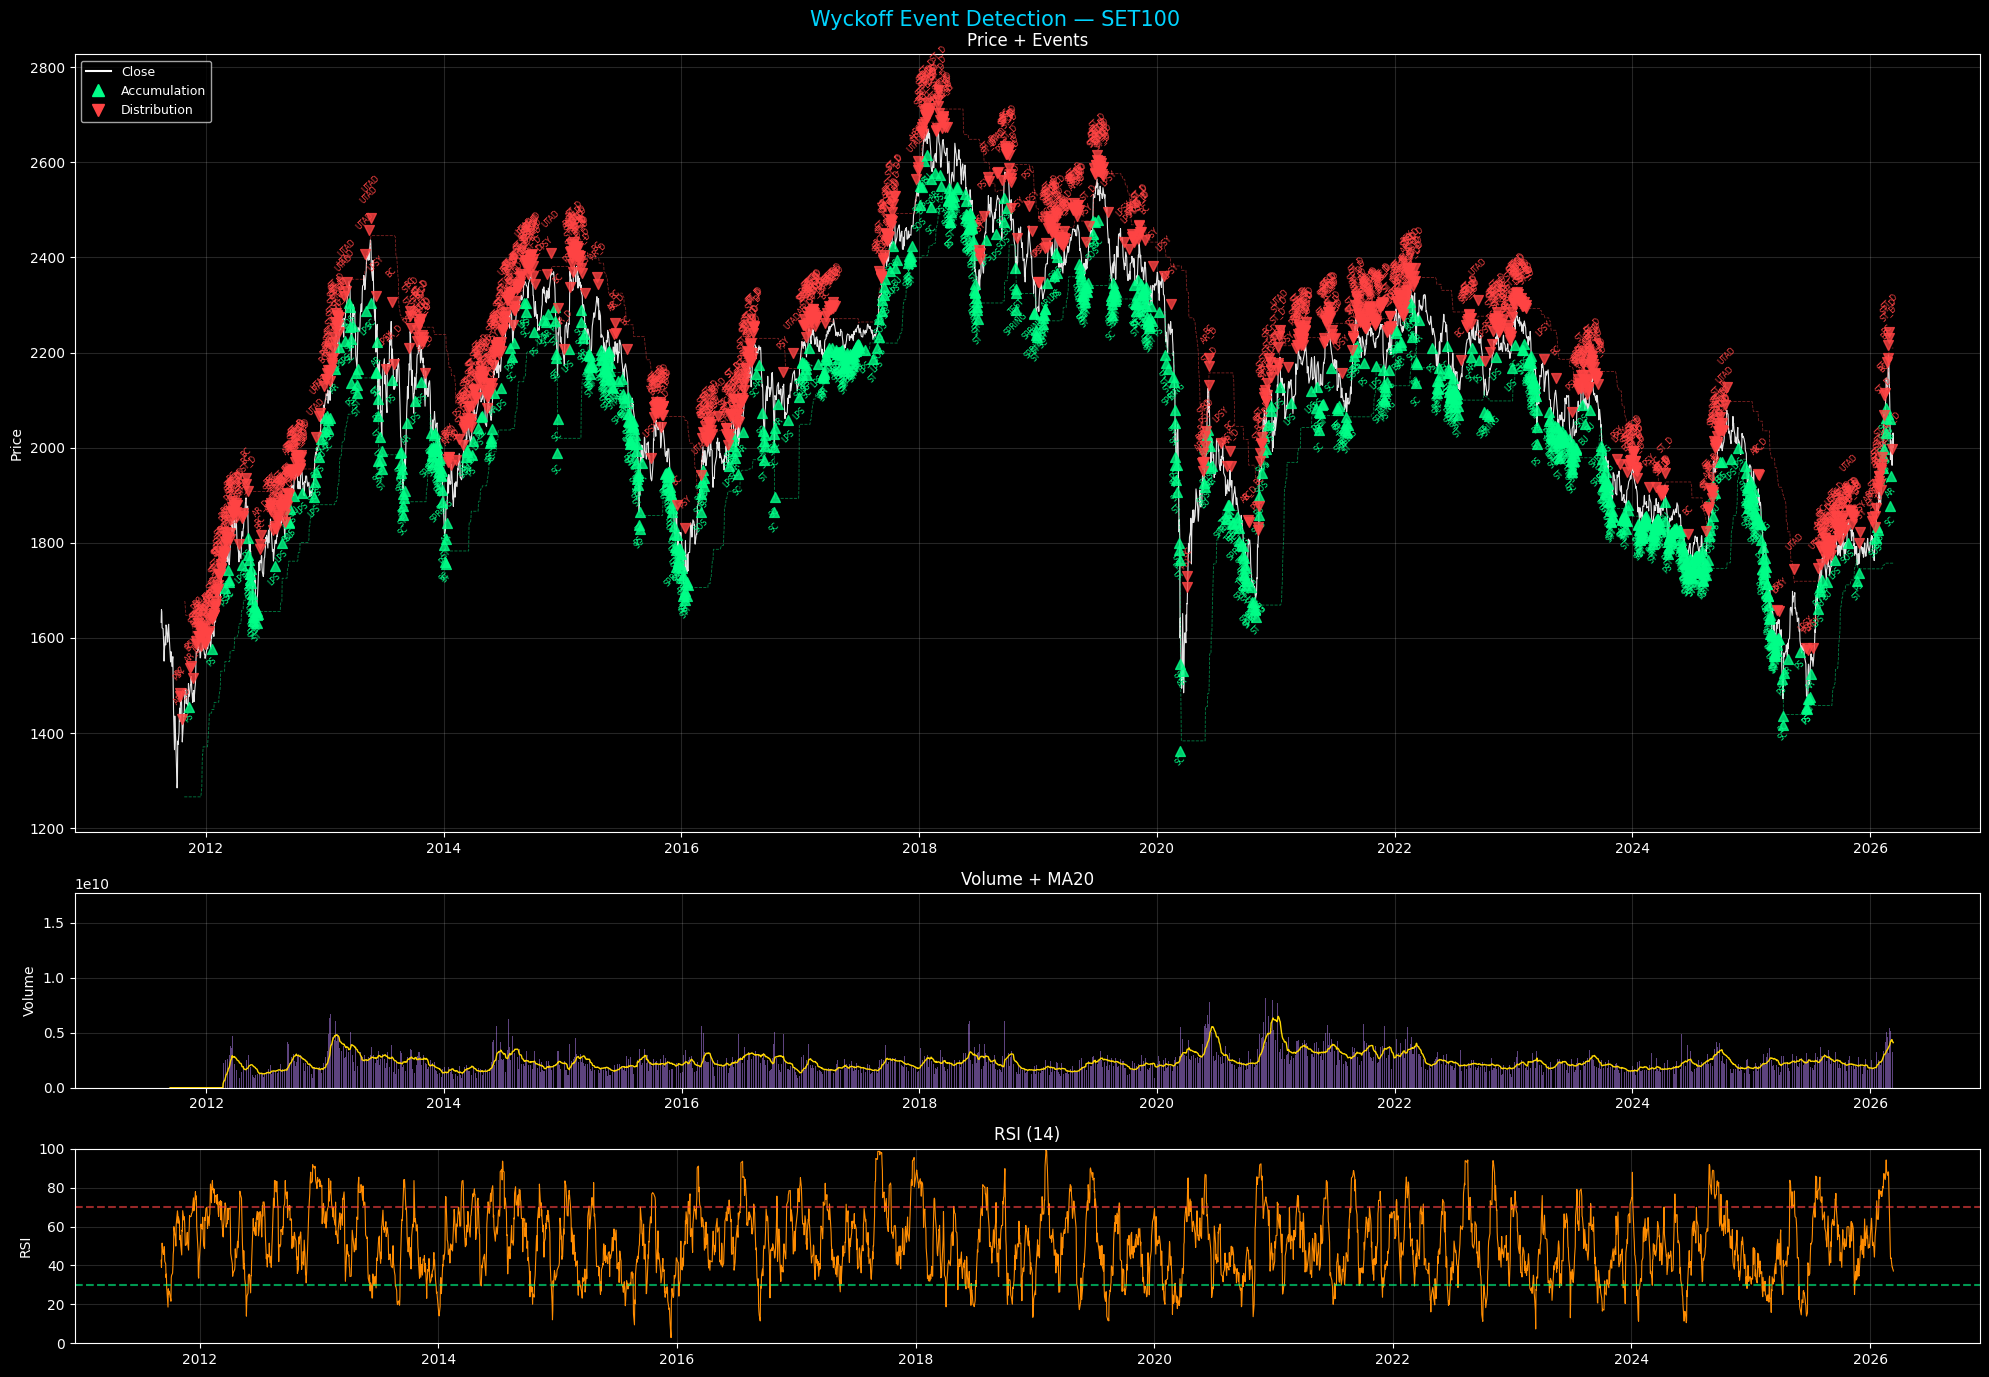

In [36]:
# ===== กราฟ: Wyckoff Event Detection Chart =====
ACCUM_COLOR = '#00FF88'
DIST_COLOR  = '#FF4444'
MARKER_OFFSET = 0.015

fig, axes = plt.subplots(3, 1, figsize=(20, 14),
                          gridspec_kw={'height_ratios': [4, 1, 1]})
fig.suptitle('Wyckoff Event Detection — SET100', fontsize=15, color=COLORS['accent'])

ax = axes[0]
ax.plot(df['Date'], df['Close'], color='white', linewidth=0.8, alpha=0.9, label='Close')
ax.plot(df['Date'], df['Support_TR'], color=COLORS['green'], linewidth=0.6,
        linestyle='--', alpha=0.5, label='Support')
ax.plot(df['Date'], df['Resistance_TR'], color=COLORS['red'], linewidth=0.6,
        linestyle='--', alpha=0.5, label='Resistance')

for event in ACCUM_EVENTS:
    ev_df = df[df['Wyckoff_Event'] == event]
    if len(ev_df) > 0:
        ax.scatter(ev_df['Date'], ev_df['Low'] * (1 - MARKER_OFFSET),
                   marker='^', s=50, color=ACCUM_COLOR, alpha=0.8, zorder=5)
        for _, row in ev_df.iterrows():
            ax.annotate(event, (row['Date'], row['Low'] * (1 - MARKER_OFFSET*2.5)),
                        fontsize=5.5, color=ACCUM_COLOR, ha='center', rotation=45)

for event in DIST_EVENTS:
    ev_df = df[df['Wyckoff_Event'] == event]
    if len(ev_df) > 0:
        ax.scatter(ev_df['Date'], ev_df['High'] * (1 + MARKER_OFFSET),
                   marker='v', s=50, color=DIST_COLOR, alpha=0.8, zorder=5)
        for _, row in ev_df.iterrows():
            ax.annotate(event, (row['Date'], row['High'] * (1 + MARKER_OFFSET*2.5)),
                        fontsize=5.5, color=DIST_COLOR, ha='center', rotation=45)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='white', label='Close'),
    Line2D([0],[0], marker='^', color=ACCUM_COLOR, linestyle='None', markersize=8, label='Accumulation'),
    Line2D([0],[0], marker='v', color=DIST_COLOR,  linestyle='None', markersize=8, label='Distribution'),
], loc='upper left', fontsize=9)
ax.set_ylabel('Price')
ax.grid(alpha=0.15)
ax.set_title('Price + Events', color='white')

axes[1].bar(df['Date'], df['Volume'], color=COLORS['purple'], alpha=0.5, width=1)
axes[1].plot(df['Date'], df['Vol_MA20'], color=COLORS['yellow'], linewidth=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Volume + MA20', color='white')
axes[1].grid(alpha=0.15)

axes[2].plot(df['Date'], df['RSI'], color=COLORS['orange'], linewidth=0.8)
axes[2].axhline(70, color=COLORS['red'],   linestyle='--', alpha=0.6)
axes[2].axhline(30, color=COLORS['green'], linestyle='--', alpha=0.6)
axes[2].set_ylabel('RSI')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14)', color='white')
axes[2].grid(alpha=0.15)

plt.tight_layout()
plt.show()

---
## 🤖 Phase 4: Modeling — Deep Learning

In [37]:
# ===== SEQUENCE BUILDER สำหรับ Deep Learning =====
print("="*70)
print("   CRISP-DM Phase 4: DATA PREPARATION FOR DEEP LEARNING")
print("   สร้าง Sequence (Sliding Window) สำหรับ LSTM / CNN")
print("="*70)

SEQ_LEN = 20   # lookback window (20 วัน)

df_dl = df.dropna(subset=DL_FEATURES).copy().reset_index(drop=True)

# Normalize features
scaler_dl = StandardScaler()
feat_scaled = scaler_dl.fit_transform(df_dl[DL_FEATURES])

def build_sequences(data, labels, seq_len):
    """สร้าง (X, y) แบบ sliding window"""
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(labels[i])
    return np.array(X), np.array(y)

N_FEATURES = len(DL_FEATURES)
print(f'✅ Sequence Length : {SEQ_LEN} วัน')
print(f'✅ Feature Count   : {N_FEATURES}')
print(f'✅ Input Shape (X) : (samples, {SEQ_LEN}, {N_FEATURES})')

   CRISP-DM Phase 4: DATA PREPARATION FOR DEEP LEARNING
   สร้าง Sequence (Sliding Window) สำหรับ LSTM / CNN
✅ Sequence Length : 20 วัน
✅ Feature Count   : 30
✅ Input Shape (X) : (samples, 20, 30)


### Part 1: Event Label Classification (Multi-Class)

In [38]:
# ===== Part 1: เตรียมข้อมูล Event Classification =====
print("="*70)
print("   Part 1: Wyckoff Event Label Classification — Deep Learning")
print("="*70)

df_labeled = df_dl[df_dl['Wyckoff_Event'] != ''].copy()

# ตัด event ที่มีน้อยกว่า 5
event_counts = df_labeled['Wyckoff_Event'].value_counts()
valid_events = event_counts[event_counts >= 5].index
df_labeled = df_labeled[df_labeled['Wyckoff_Event'].isin(valid_events)].copy()

le = LabelEncoder()
df_labeled['y_enc'] = le.fit_transform(df_labeled['Wyckoff_Event'])
N_CLASSES = len(le.classes_)

print('\n📊 ตาราง: Event Distribution (Part 1)')
ev_dist = pd.DataFrame({
    'Event':   event_counts.index[:20],
    'Count':   event_counts.values[:20],
    'Pct (%)': (event_counts.values[:20] / event_counts.sum() * 100).round(2),
})
display(ev_dist)
print(f'\nClasses: {list(le.classes_)} | จำนวน: {N_CLASSES}')

# Rebuild feat_scaled เฉพาะแถวที่มี event
feat_labeled = scaler_dl.transform(df_labeled[DL_FEATURES])
labels_p1    = df_labeled['y_enc'].values

X_p1, y_p1 = build_sequences(feat_labeled, labels_p1, SEQ_LEN)
print(f'\nX shape: {X_p1.shape} | y shape: {y_p1.shape}')

# One-hot encode สำหรับ categorical crossentropy
y_p1_oh = keras.utils.to_categorical(y_p1, num_classes=N_CLASSES)

# Train/Test split (stratified)
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_p1, y_p1_oh, test_size=0.2, random_state=42)
y_te1_cls = np.argmax(y_te1, axis=1)

print('\n📊 ตาราง: Data Split')
display(pd.DataFrame({
    'Set': ['Train','Test'],
    'Samples': [len(X_tr1), len(X_te1)],
    'Shape X': [str(X_tr1.shape), str(X_te1.shape)],
}))

   Part 1: Wyckoff Event Label Classification — Deep Learning

📊 ตาราง: Event Distribution (Part 1)


,Event,Count,Pct (%)
0,ST_D,781,37.2800
1,ST,556,26.5400
2,BC,160,7.6400
3,SC,119,5.6800
4,PS,73,3.4800
5,PSY,64,3.0500
6,SOS,61,2.9100
7,AR_D,57,2.7200
8,AR,57,2.7200
9,LPS,39,1.8600



Classes: ['AR', 'AR_D', 'BC', 'BU', 'LPS', 'LPSY', 'PS', 'PSY', 'SC', 'SOS', 'SPRING', 'ST', 'ST_D', 'TEST', 'UTAD'] | จำนวน: 15

X shape: (2074, 20, 30) | y shape: (2074,)

📊 ตาราง: Data Split


,Set,Samples,Shape X
0,Train,1659,"(1659, 20, 30)"
1,Test,415,"(415, 20, 30)"


In [39]:
# ===== Part 1: สร้าง Deep Learning Models =====
print('🔨 สร้าง Deep Learning Models...')

def build_lstm(seq_len, n_feat, n_classes, units=64, dropout=0.3):
    """Stacked LSTM"""
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        LSTM(units, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),
        LSTM(units // 2),
        BatchNormalization(),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout / 2),
        Dense(n_classes, activation='softmax'),
    ], name='LSTM')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(seq_len, n_feat, n_classes, units=64, dropout=0.3):
    """Bidirectional LSTM"""
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        Bidirectional(LSTM(units, return_sequences=True)),
        BatchNormalization(),
        Dropout(dropout),
        Bidirectional(LSTM(units // 2)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout / 2),
        Dense(n_classes, activation='softmax'),
    ], name='BiLSTM')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn1d(seq_len, n_feat, n_classes, filters=64, dropout=0.3):
    """1D CNN"""
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        Conv1D(filters, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters * 2, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(n_classes, activation='softmax'),
    ], name='Conv1D')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnnlstm(seq_len, n_feat, n_classes, filters=64, units=64, dropout=0.3):
    """CNN + LSTM Hybrid"""
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        Conv1D(filters, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        LSTM(units, return_sequences=False),
        BatchNormalization(),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout / 2),
        Dense(n_classes, activation='softmax'),
    ], name='CNN_LSTM')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

models_p1 = {
    'LSTM':     build_lstm(SEQ_LEN, N_FEATURES, N_CLASSES),
    'BiLSTM':   build_bilstm(SEQ_LEN, N_FEATURES, N_CLASSES),
    'Conv1D':   build_cnn1d(SEQ_LEN, N_FEATURES, N_CLASSES),
    'CNN-LSTM': build_cnnlstm(SEQ_LEN, N_FEATURES, N_CLASSES),
}

print('\n📊 ตาราง: Model Architecture Summary')
arch_rows = []
for name, m in models_p1.items():
    arch_rows.append({
        'Model':      name,
        'Params':     f'{m.count_params():,}',
        'Layers':     len(m.layers),
        'Output':     str(m.output_shape),
    })
display(pd.DataFrame(arch_rows))

🔨 สร้าง Deep Learning Models...

📊 ตาราง: Model Architecture Summary


,Model,Params,Layers,Output
0,LSTM,"40,207",9,"(None, 15)"
1,BiLSTM,"95,759",9,"(None, 15)"
2,Conv1D,"40,527",8,"(None, 15)"
3,CNN-LSTM,"44,495",9,"(None, 15)"


In [40]:
# ===== Part 1: เทรน Deep Learning Models =====
print('🔄 เทรน Part 1 — Event Classification...')

EPOCHS    = 50
BATCH     = 32
PATIENCE  = 10

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True, verbose=0)
reduce_lr  = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0)

history_p1  = {}
results_p1  = {}

for name, model in models_p1.items():
    print(f'  ▶ เทรน {name}...', end=' ')
    hist = model.fit(
        X_tr1, y_tr1,
        epochs=EPOCHS, batch_size=BATCH,
        validation_split=0.15,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    y_prob = model.predict(X_te1, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc    = accuracy_score(y_te1_cls, y_pred)
    f1_wt  = f1_score(y_te1_cls, y_pred, average='weighted', zero_division=0)
    f1_mac = f1_score(y_te1_cls, y_pred, average='macro', zero_division=0)

    history_p1[name]  = hist
    results_p1[name]  = {
        'model': model, 'accuracy': acc,
        'f1_weighted': f1_wt, 'f1_macro': f1_mac,
        'y_pred': y_pred, 'y_prob': y_prob,
        'epochs_ran': len(hist.history['accuracy']),
    }
    print(f'Acc={acc:.4f} | F1(wt)={f1_wt:.4f} | Epochs={len(hist.history["accuracy"])}')

best_p1 = max(results_p1, key=lambda k: results_p1[k]['accuracy'])
print(f'\n🏆 Best Model (Part 1): {best_p1} (Acc={results_p1[best_p1]["accuracy"]:.4f})')

🔄 เทรน Part 1 — Event Classification...
  ▶ เทรน LSTM... Acc=0.6169 | F1(wt)=0.5092 | Epochs=29
  ▶ เทรน BiLSTM... Acc=0.5976 | F1(wt)=0.4675 | Epochs=10
  ▶ เทรน Conv1D... Acc=0.5398 | F1(wt)=0.4519 | Epochs=10
  ▶ เทรน CNN-LSTM... Acc=0.5735 | F1(wt)=0.4830 | Epochs=10

🏆 Best Model (Part 1): LSTM (Acc=0.6169)


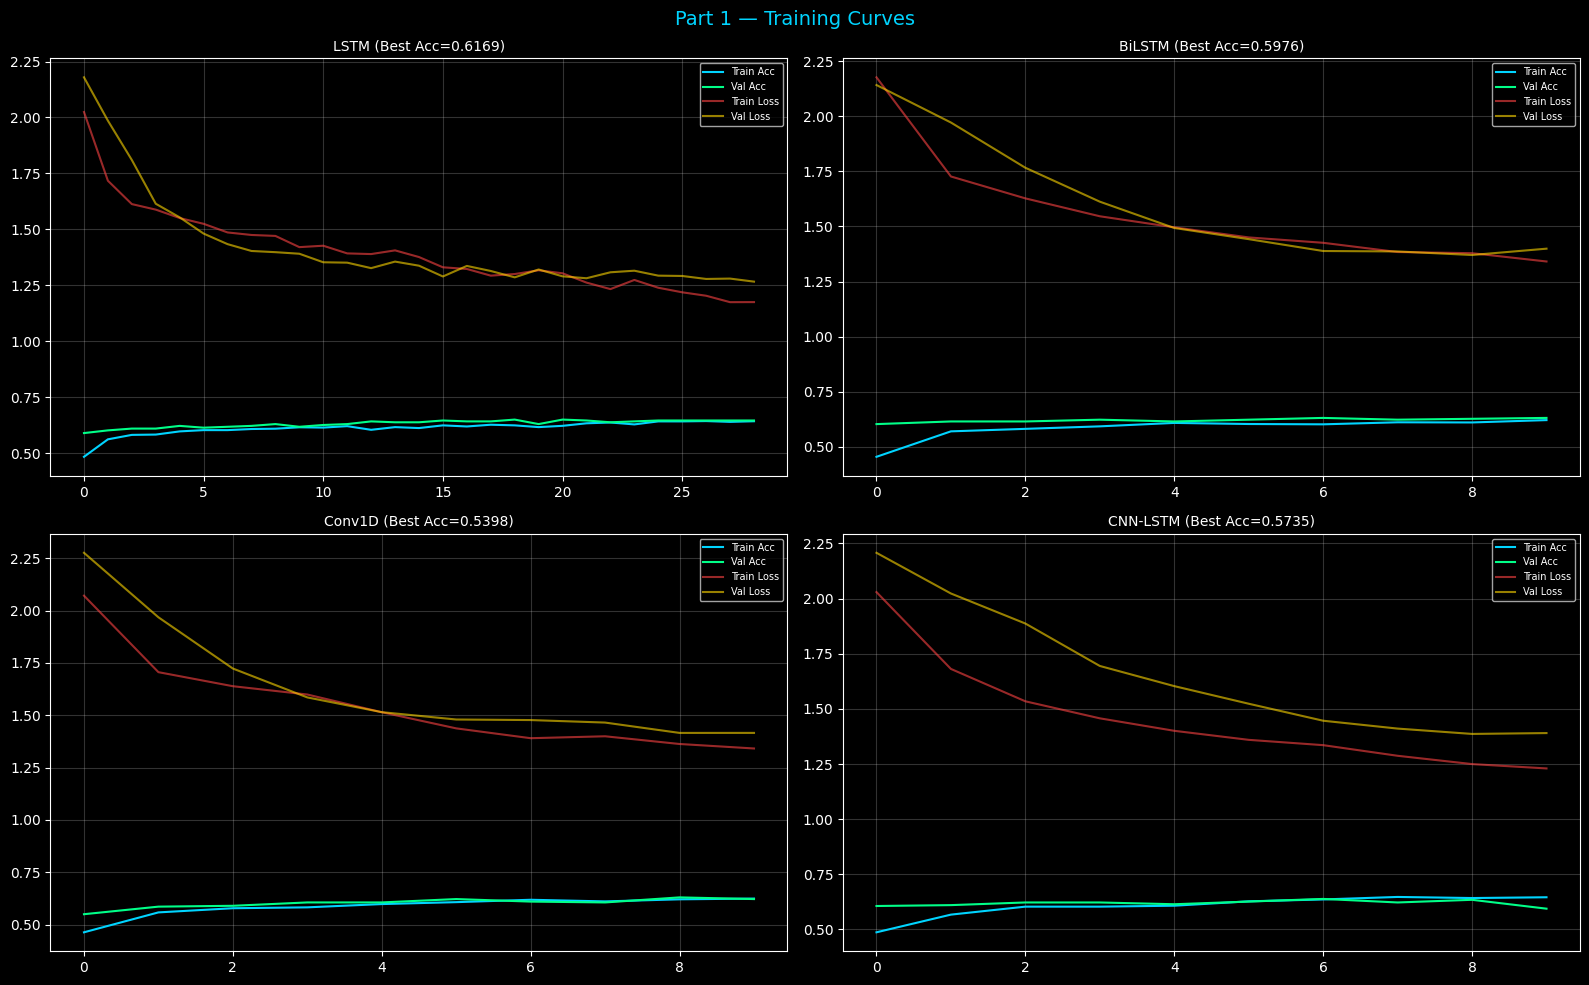

In [50]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Part 1 — Training Curves', fontsize=14, color=COLORS['accent'])
for ax, (name, hist) in zip(axes.flat, history_p1.items()):
    ax.plot(hist.history['accuracy'],     color=COLORS['accent'],  label='Train Acc')
    ax.plot(hist.history['val_accuracy'], color=COLORS['green'],   label='Val Acc')
    ax.plot(hist.history['loss'],         color=COLORS['red'],     label='Train Loss', alpha=0.6)
    ax.plot(hist.history['val_loss'],     color=COLORS['yellow'],  label='Val Loss',   alpha=0.6)
    ax.set_title(f'{name} (Best Acc={results_p1[name]["accuracy"]:.4f})', color='white', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

📊 ตาราง: Classification Report — LSTM


,precision,recall,f1-score,support
AR,0.0000,0.0000,0.0000,18.0000
AR_D,0.0000,0.0000,0.0000,9.0000
BC,0.2273,0.2000,0.2128,25.0000
BU,0.0000,0.0000,0.0000,9.0000
LPS,0.0000,0.0000,0.0000,10.0000
LPSY,0.0000,0.0000,0.0000,6.0000
PS,0.0000,0.0000,0.0000,12.0000
PSY,0.0000,0.0000,0.0000,9.0000
SC,0.0000,0.0000,0.0000,26.0000
SOS,0.0000,0.0000,0.0000,10.0000


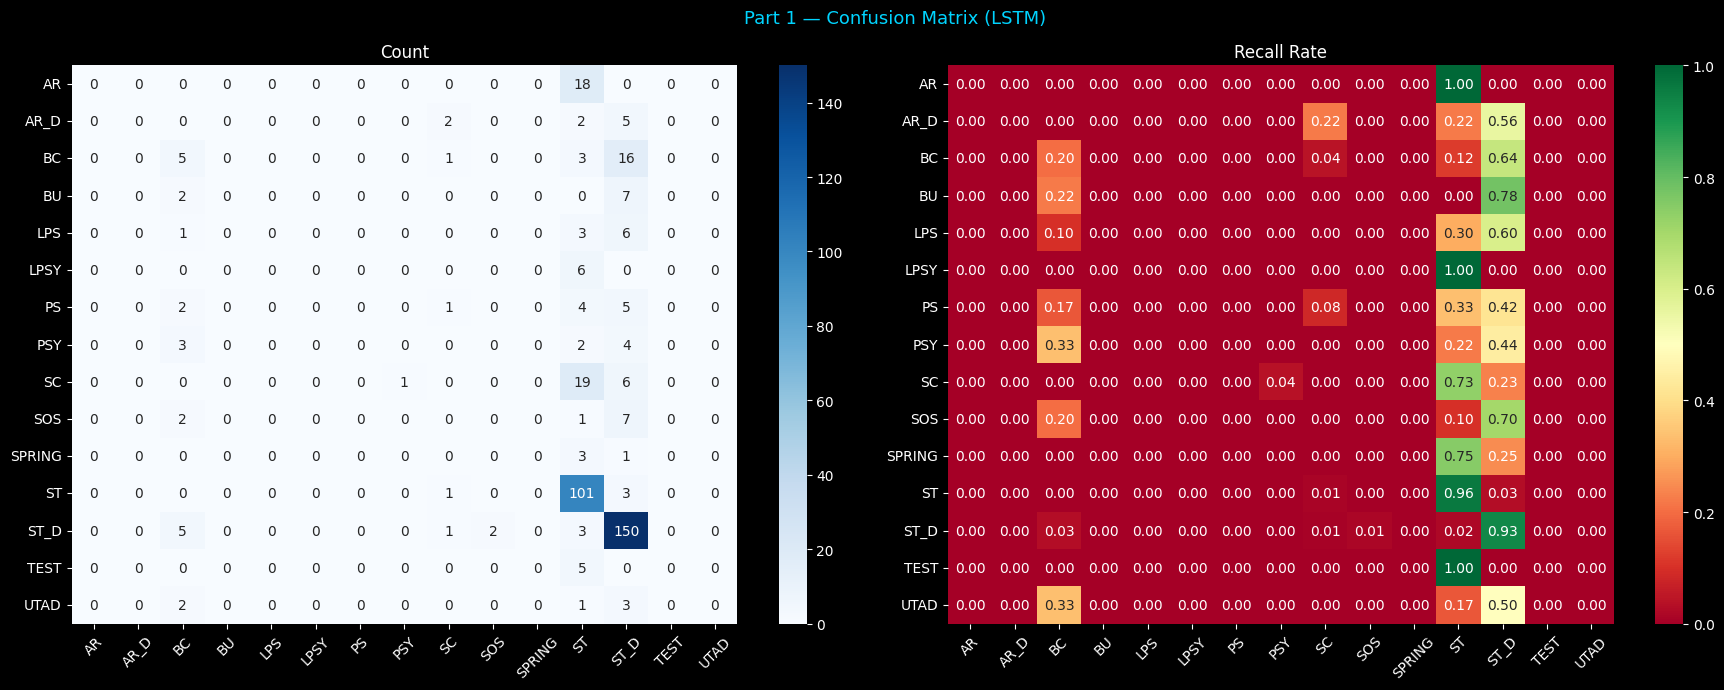

In [51]:
# ===== Part 1: Classification Report + Confusion Matrix =====
best_res1 = results_p1[best_p1]

print(f'📊 ตาราง: Classification Report — {best_p1}')
cr = classification_report(y_te1_cls, best_res1['y_pred'],
     target_names=le.classes_, output_dict=True, zero_division=0)
display(pd.DataFrame(cr).T.round(4))

cm = confusion_matrix(y_te1_cls, best_res1['y_pred'])
cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Part 1 — Confusion Matrix ({best_p1})', fontsize=13, color=COLORS['accent'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Count', color='white')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Recall Rate', color='white')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Part 2: Return Direction Prediction (Binary)

In [43]:
# ===== Part 2: เตรียมข้อมูล Return Direction =====
print("="*70)
print("   Part 2: Return Direction Prediction — Deep Learning")
print("="*70)

FORWARD_DAYS = 10
df_dl['Future_Return']    = df_dl['Close'].shift(-FORWARD_DAYS) / df_dl['Close'] - 1
df_dl['Target_Direction'] = (df_dl['Future_Return'] > 0).astype(int)

df_p2 = df_dl.dropna(subset=DL_FEATURES + ['Target_Direction']).copy().reset_index(drop=True)
feat_p2_scaled = scaler_dl.transform(df_p2[DL_FEATURES])
labels_p2      = df_p2['Target_Direction'].values

X_p2, y_p2 = build_sequences(feat_p2_scaled, labels_p2, SEQ_LEN)
print(f'\n✅ X_p2 shape: {X_p2.shape} | Positive: {y_p2.sum()}/{len(y_p2)}')

# Time-series split (ไม่สุ่ม — ป้องกัน data leakage)
split_idx  = int(len(X_p2) * 0.80)
X_tr2, X_te2 = X_p2[:split_idx], X_p2[split_idx:]
y_tr2, y_te2 = y_p2[:split_idx], y_p2[split_idx:]

print('\n📊 ตาราง: Time-Series Split')
display(pd.DataFrame({
    'Set':     ['Train','Test'],
    'Samples': [len(X_tr2), len(X_te2)],
    'Positive Rate': [f'{y_tr2.mean():.3f}', f'{y_te2.mean():.3f}'],
}))

   Part 2: Return Direction Prediction — Deep Learning

✅ X_p2 shape: (3484, 20, 30) | Positive: 1803/3484

📊 ตาราง: Time-Series Split


,Set,Samples,Positive Rate
0,Train,2787,0.532
1,Test,697,0.459


In [44]:
# ===== Part 2: สร้าง + เทรน DL Models (Binary) =====
print('🔄 เทรน Part 2 — Return Direction...')

def build_lstm_bin(seq_len, n_feat, units=64, dropout=0.3):
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        LSTM(units, return_sequences=True),
        BatchNormalization(), Dropout(dropout),
        LSTM(units // 2),
        BatchNormalization(), Dropout(dropout),
        Dense(32, activation='relu'), Dropout(dropout / 2),
        Dense(1, activation='sigmoid'),
    ], name='LSTM_bin')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm_bin(seq_len, n_feat, units=64, dropout=0.3):
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        Bidirectional(LSTM(units, return_sequences=True)),
        BatchNormalization(), Dropout(dropout),
        Bidirectional(LSTM(units // 2)),
        BatchNormalization(), Dropout(dropout),
        Dense(32, activation='relu'), Dropout(dropout / 2),
        Dense(1, activation='sigmoid'),
    ], name='BiLSTM_bin')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn1d_bin(seq_len, n_feat, filters=64, dropout=0.3):
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        Conv1D(filters, 3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters*2, 3, activation='relu', padding='same'),
        BatchNormalization(), GlobalAveragePooling1D(),
        Dense(32, activation='relu'), Dropout(dropout),
        Dense(1, activation='sigmoid'),
    ], name='Conv1D_bin')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnnlstm_bin(seq_len, n_feat, filters=64, units=64, dropout=0.3):
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        Conv1D(filters, 3, activation='relu', padding='same'),
        BatchNormalization(), MaxPooling1D(2),
        LSTM(units),
        BatchNormalization(), Dropout(dropout),
        Dense(32, activation='relu'), Dropout(dropout / 2),
        Dense(1, activation='sigmoid'),
    ], name='CNN_LSTM_bin')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models_p2 = {
    'LSTM':     build_lstm_bin(SEQ_LEN, N_FEATURES),
    'BiLSTM':   build_bilstm_bin(SEQ_LEN, N_FEATURES),
    'Conv1D':   build_cnn1d_bin(SEQ_LEN, N_FEATURES),
    'CNN-LSTM': build_cnnlstm_bin(SEQ_LEN, N_FEATURES),
}

early_stop2 = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True, verbose=0)
reduce_lr2  = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0)

history_p2 = {}
results_p2 = {}

for name, model in models_p2.items():
    print(f'  ▶ เทรน {name}...', end=' ')
    hist = model.fit(
        X_tr2, y_tr2,
        epochs=EPOCHS, batch_size=BATCH,
        validation_split=0.15,
        callbacks=[early_stop2, reduce_lr2],
        verbose=0
    )
    y_prob = model.predict(X_te2, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    acc    = accuracy_score(y_te2, y_pred)
    auc    = roc_auc_score(y_te2, y_prob)
    f1     = f1_score(y_te2, y_pred, zero_division=0)

    history_p2[name] = hist
    results_p2[name] = {
        'model': model, 'acc': acc, 'auc': auc, 'f1': f1,
        'y_pred': y_pred, 'y_prob': y_prob,
        'epochs_ran': len(hist.history['accuracy']),
    }
    print(f'Acc={acc:.4f} | AUC={auc:.4f} | F1={f1:.4f} | Epochs={len(hist.history["accuracy"])}')

best_p2 = max(results_p2, key=lambda k: results_p2[k]['auc'])
print(f'\n🏆 Best Model (Part 2): {best_p2} (AUC={results_p2[best_p2]["auc"]:.4f})')

🔄 เทรน Part 2 — Return Direction...
  ▶ เทรน LSTM... Acc=0.5395 | AUC=0.5437 | F1=0.4729 | Epochs=25
  ▶ เทรน BiLSTM... Acc=0.4519 | AUC=0.4174 | F1=0.6203 | Epochs=10
  ▶ เทรน Conv1D... Acc=0.4591 | AUC=0.5556 | F1=0.6226 | Epochs=10
  ▶ เทรน CNN-LSTM... Acc=0.4878 | AUC=0.4906 | F1=0.4233 | Epochs=18

🏆 Best Model (Part 2): Conv1D (AUC=0.5556)



📊 ตาราง: Model Comparison — Part 2


,Model,Accuracy,AUC-ROC,F1 Score,Epochs Run,Best
0,LSTM,0.5395,0.5437,0.4729,25,
1,BiLSTM,0.4519,0.4174,0.6203,10,
2,Conv1D,0.4591,0.5556,0.6226,10,⭐
3,CNN-LSTM,0.4878,0.4906,0.4233,18,


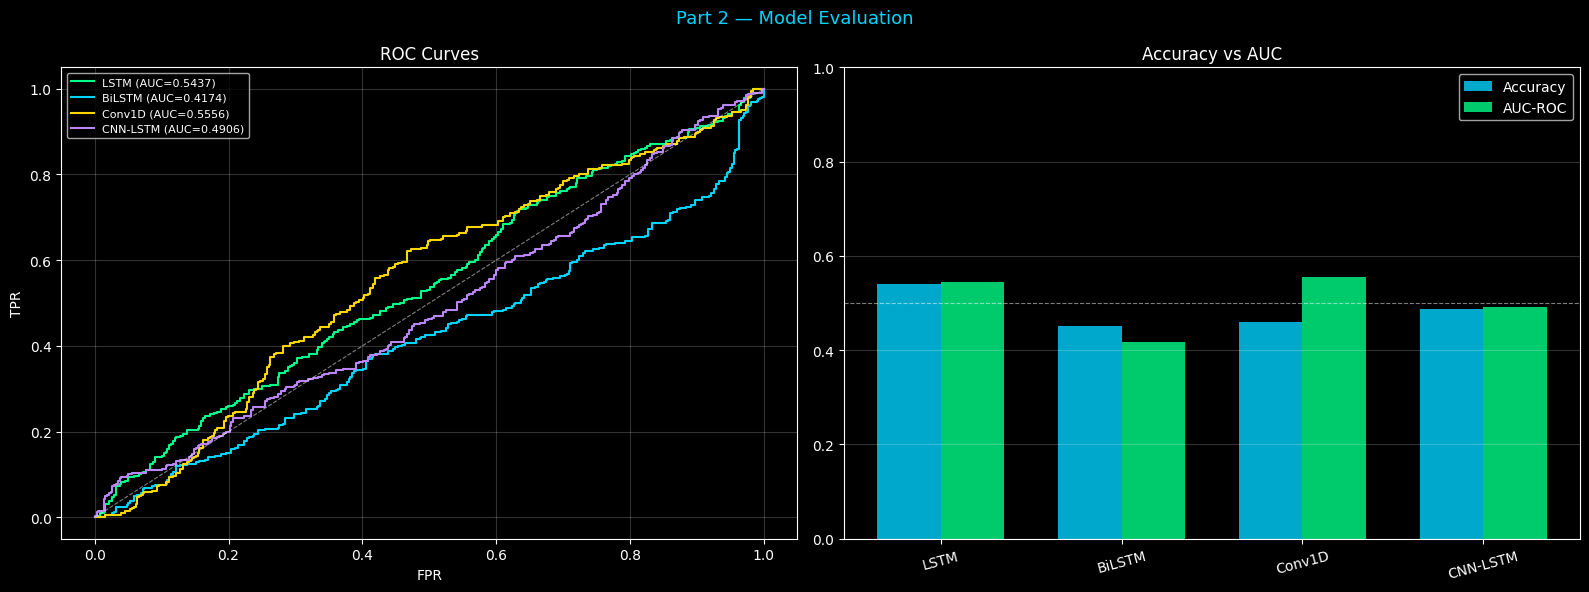

In [45]:
# ===== Part 2: ตาราง + ROC Curves =====
print('\n📊 ตาราง: Model Comparison — Part 2')
comp2 = pd.DataFrame([{
    'Model':      n,
    'Accuracy':   f"{v['acc']:.4f}",
    'AUC-ROC':    f"{v['auc']:.4f}",
    'F1 Score':   f"{v['f1']:.4f}",
    'Epochs Run': v['epochs_ran'],
    'Best':       '⭐' if n == best_p2 else '',
} for n, v in results_p2.items()])
display(comp2)

# ROC + Bar comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Part 2 — Model Evaluation', fontsize=13, color=COLORS['accent'])

clrs = [COLORS['green'], COLORS['accent'], COLORS['yellow'], COLORS['purple']]
for (name, v), c in zip(results_p2.items(), clrs):
    fpr, tpr, _ = roc_curve(y_te2, v['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.4f})", color=c, linewidth=1.5)
axes[0].plot([0,1],[0,1],'w--',linewidth=0.8,alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)

names = list(results_p2.keys())
x = np.arange(len(names)); w = 0.35
axes[1].bar(x - w/2, [results_p2[n]['acc'] for n in names], w,
            label='Accuracy', color=COLORS['accent'], alpha=0.8)
axes[1].bar(x + w/2, [results_p2[n]['auc'] for n in names], w,
            label='AUC-ROC',  color=COLORS['green'],  alpha=0.8)
axes[1].axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylim(0, 1); axes[1].set_title('Accuracy vs AUC')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout(); plt.show()

In [46]:
# ===== Part 2: Win Rate แยกตาม Wyckoff Event =====
print("="*70)
print(f"   Win Rate by Wyckoff Event ({FORWARD_DAYS}-day forward) — {best_p2}")
print("="*70)

# Map DL predictions กลับไปยัง original df
df_p2_idx = df_dl.dropna(subset=DL_FEATURES + ['Target_Direction']).copy().reset_index(drop=True)
n_seq     = len(df_p2_idx) - SEQ_LEN
test_start = SEQ_LEN + split_idx

df_test_p2 = df_p2_idx.iloc[test_start : test_start + len(y_te2)].copy()
df_test_p2['ML_Pred']    = results_p2[best_p2]['y_pred']
df_test_p2['ML_Prob']    = results_p2[best_p2]['y_prob']
df_test_p2['ML_Correct'] = (df_test_p2['ML_Pred'] == df_test_p2['Target_Direction'])

event_mask = df_test_p2['Wyckoff_Event'] != ''
event_perf = df_test_p2[event_mask].groupby('Wyckoff_Event').agg(
    Count          = ('ML_Correct','count'),
    Win_Rate       = ('ML_Correct','mean'),
    Actual_Up_Rate = ('Target_Direction','mean'),
    Avg_Return     = ('Future_Return','mean'),
    Avg_Prob       = ('ML_Prob','mean'),
).sort_values('Win_Rate', ascending=False)

event_perf['Phase'] = [
    df[df['Wyckoff_Event']==e]['Wyckoff_Phase'].mode()[0]
    if len(df[df['Wyckoff_Event']==e]) > 0 else ''
    for e in event_perf.index
]
event_perf['Signal'] = event_perf['Win_Rate'].apply(
    lambda r: '🟢 Strong' if r >= 0.6 else '🟡 Moderate' if r >= 0.5 else '🔴 Weak')

print('\n📊 ตาราง: Win Rate แยกตาม Wyckoff Event')
display(event_perf.round(4))

   Win Rate by Wyckoff Event (10-day forward) — Conv1D

📊 ตาราง: Win Rate แยกตาม Wyckoff Event


,Count,Win_Rate,Actual_Up_Rate,Avg_Return,Avg_Prob,Phase,Signal
Wyckoff_Event,,,,,,,
BU,10,0.6000,0.6000,0.0073,0.5762,Accumulation,🟢 Strong
SOS,17,0.5882,0.5882,0.0075,0.5746,Accumulation,🟡 Moderate
ST_D,133,0.5263,0.5338,0.0074,0.5694,Distribution,🟡 Moderate
ST,201,0.5075,0.4975,-0.0014,0.5602,Accumulation,🟡 Moderate
AR,14,0.5000,0.5000,0.0008,0.5669,Accumulation,🟡 Moderate
BC,24,0.5000,0.5417,-0.0001,0.5647,Distribution,🟡 Moderate
PS,16,0.5000,0.4375,0.0039,0.5525,Accumulation,🟡 Moderate
SC,27,0.4815,0.4444,-0.0036,0.5636,Accumulation,🔴 Weak
LPS,5,0.4000,0.4000,0.0073,0.5507,Accumulation,🔴 Weak


   Backtest — DL Signal Strategy vs Buy & Hold

📊 ตาราง: Backtest Performance


,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%),Avg Daily Ret (%)
0,Buy & Hold,-3.4200,0.0026,-31.6600,0.0002
1,DL Signal (Conv1D),-0.8100,0.0612,-28.9900,0.0039
2,DL Strong (>0.55),4.2400,0.1787,-21.6800,0.0096


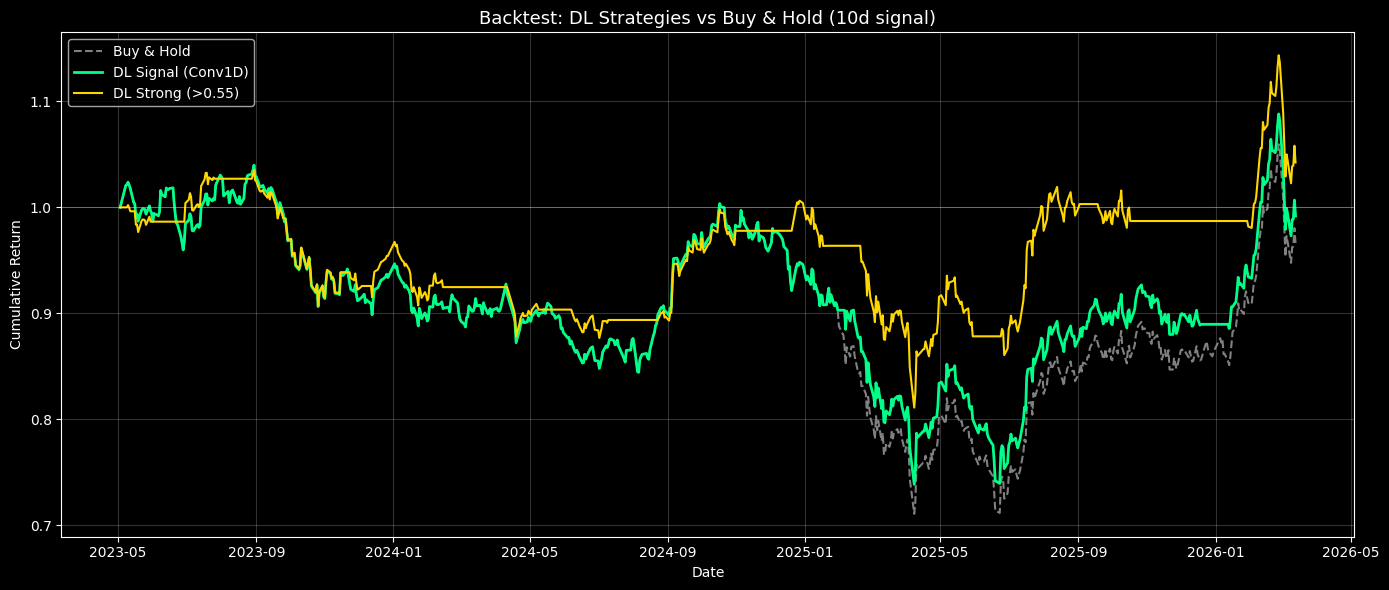

In [47]:
# ===== Part 2: Backtest Strategy =====
print("="*70)
print("   Backtest — DL Signal Strategy vs Buy & Hold")
print("="*70)

PROB_THRESH = 0.55

df_bt = df_test_p2.copy()
df_bt['Daily_Return']     = df_bt['Close'].pct_change().fillna(0)
df_bt['Strong_Signal']    = (df_bt['ML_Prob'] > PROB_THRESH).astype(int)
df_bt['Strategy_Return']  = df_bt['ML_Pred'].shift(1).fillna(0) * df_bt['Daily_Return']
df_bt['Strategy2_Return'] = df_bt['Strong_Signal'].shift(1).fillna(0) * df_bt['Daily_Return']
df_bt['Cum_BH']  = (1 + df_bt['Daily_Return']).cumprod()
df_bt['Cum_ML']  = (1 + df_bt['Strategy_Return']).cumprod()
df_bt['Cum_ML2'] = (1 + df_bt['Strategy2_Return']).cumprod()

def sharpe(r, rf=0):
    ex = r - rf/252
    return (ex.mean() / (ex.std() + 1e-10)) * np.sqrt(252)

def max_dd(cum):
    return ((cum - cum.cummax()) / cum.cummax()).min()

metrics = pd.DataFrame({
    'Strategy':           ['Buy & Hold', f'DL Signal ({best_p2})', f'DL Strong (>{PROB_THRESH})'],
    'Total Return (%)':   [round((df_bt['Cum_BH'].iloc[-1]-1)*100,2),
                           round((df_bt['Cum_ML'].iloc[-1]-1)*100,2),
                           round((df_bt['Cum_ML2'].iloc[-1]-1)*100,2)],
    'Sharpe Ratio':       [round(sharpe(df_bt['Daily_Return']),4),
                           round(sharpe(df_bt['Strategy_Return']),4),
                           round(sharpe(df_bt['Strategy2_Return']),4)],
    'Max Drawdown (%)':   [round(max_dd(df_bt['Cum_BH'])*100,2),
                           round(max_dd(df_bt['Cum_ML'])*100,2),
                           round(max_dd(df_bt['Cum_ML2'])*100,2)],
    'Avg Daily Ret (%)':  [round(df_bt['Daily_Return'].mean()*100,4),
                           round(df_bt['Strategy_Return'].mean()*100,4),
                           round(df_bt['Strategy2_Return'].mean()*100,4)],
})

print('\n📊 ตาราง: Backtest Performance')
display(metrics)

plt.figure(figsize=(14, 6))
plt.plot(df_bt['Date'].values, df_bt['Cum_BH'].values,  color='gray', linestyle='--', linewidth=1.5, label='Buy & Hold')
plt.plot(df_bt['Date'].values, df_bt['Cum_ML'].values,  color=COLORS['green'],  linewidth=2,   label=f'DL Signal ({best_p2})')
plt.plot(df_bt['Date'].values, df_bt['Cum_ML2'].values, color=COLORS['yellow'], linewidth=1.5, label=f'DL Strong (>{PROB_THRESH})')
plt.axhline(1.0, color='white', linewidth=0.5, alpha=0.4)
plt.title(f'Backtest: DL Strategies vs Buy & Hold ({FORWARD_DAYS}d signal)', fontsize=13)
plt.ylabel('Cumulative Return'); plt.xlabel('Date')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

---
## 📊 Phase 5: Evaluation — Walk-Forward Validation

   CRISP-DM Phase 5: EVALUATION
   Walk-Forward Validation — Best DL Model
  Fold 1: Acc=0.5569 | AUC=0.5367
  Fold 2: Acc=0.5328 | AUC=0.5340
  Fold 3: Acc=0.5655 | AUC=0.5845
  Fold 4: Acc=0.5155 | AUC=0.5249
  Fold 5: Acc=0.4983 | AUC=0.4507

📊 ตาราง: Walk-Forward Validation


,Fold,Train Size,Test Size,Accuracy,AUC-ROC
0,1,584,580,0.5569,0.5367
1,2,1164,580,0.5328,0.5340
2,3,1744,580,0.5655,0.5845
3,4,2324,580,0.5155,0.5249
4,5,2904,580,0.4983,0.4507



📊 ตาราง: Walk-Forward Summary


,Metric,Mean,Std,Min,Max
0,Accuracy,0.5338,0.0280,0.4983,0.5655
1,AUC-ROC,0.5262,0.0481,0.4507,0.5845


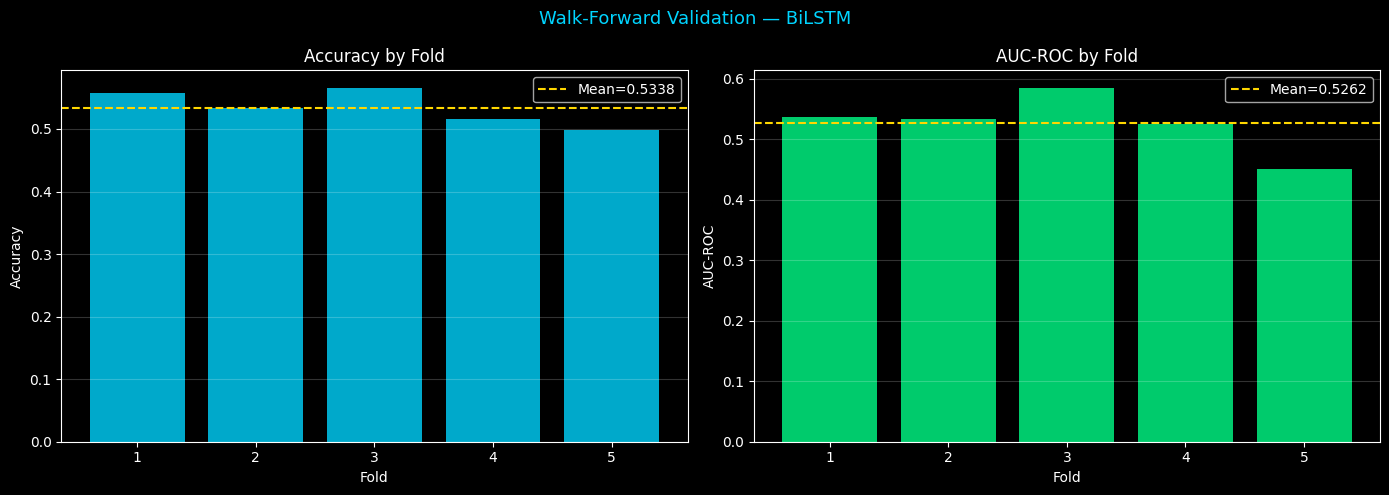

In [48]:
# ===== Walk-Forward Validation (Time-Series CV) =====
print("="*70)
print("   CRISP-DM Phase 5: EVALUATION")
print("   Walk-Forward Validation — Best DL Model")
print("="*70)

N_SPLITS  = 5
tscv      = TimeSeriesSplit(n_splits=N_SPLITS)
wf_results = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_p2), 1):
    X_tr_wf, X_te_wf = X_p2[tr_idx], X_p2[te_idx]
    y_tr_wf, y_te_wf = y_p2[tr_idx], y_p2[te_idx]

    wf_model = build_bilstm_bin(SEQ_LEN, N_FEATURES)
    wf_model.fit(X_tr_wf, y_tr_wf,
                 epochs=30, batch_size=BATCH,
                 validation_split=0.1,
                 callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
                 verbose=0)
    y_pb = wf_model.predict(X_te_wf, verbose=0).flatten()
    y_pr = (y_pb > 0.5).astype(int)
    acc  = accuracy_score(y_te_wf, y_pr)
    auc  = roc_auc_score(y_te_wf, y_pb) if len(np.unique(y_te_wf)) > 1 else 0.5
    wf_results.append({'Fold': fold, 'Train Size': len(tr_idx), 'Test Size': len(te_idx),
                        'Accuracy': round(acc,4), 'AUC-ROC': round(auc,4)})
    print(f'  Fold {fold}: Acc={acc:.4f} | AUC={auc:.4f}')

wf_df = pd.DataFrame(wf_results)
print('\n📊 ตาราง: Walk-Forward Validation')
display(wf_df)

print('\n📊 ตาราง: Walk-Forward Summary')
display(pd.DataFrame({
    'Metric': ['Accuracy','AUC-ROC'],
    'Mean':   [wf_df['Accuracy'].mean().round(4), wf_df['AUC-ROC'].mean().round(4)],
    'Std':    [wf_df['Accuracy'].std().round(4),  wf_df['AUC-ROC'].std().round(4)],
    'Min':    [wf_df['Accuracy'].min(), wf_df['AUC-ROC'].min()],
    'Max':    [wf_df['Accuracy'].max(), wf_df['AUC-ROC'].max()],
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Walk-Forward Validation — BiLSTM', fontsize=13, color=COLORS['accent'])
for ax, col, color, title in zip(
        axes, ['Accuracy','AUC-ROC'],
        [COLORS['accent'], COLORS['green']],
        ['Accuracy by Fold','AUC-ROC by Fold']):
    ax.bar(wf_df['Fold'], wf_df[col], color=color, alpha=0.8)
    ax.axhline(wf_df[col].mean(), color=COLORS['yellow'], linestyle='--',
               label=f"Mean={wf_df[col].mean():.4f}")
    ax.set_xlabel('Fold'); ax.set_ylabel(col); ax.set_title(title)
    ax.legend(); ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

---
## 🖥️ Phase 6: Deployment — Research Dashboard

In [49]:
# ===== Summary Tables =====
print("="*70)
print("   CRISP-DM Phase 6: DEPLOYMENT / REPORTING")
print("="*70)

print('\n📊 [TABLE 1] DL Model Summary — Part 1 (Event Classification)')
display(comp1)

print('\n📊 [TABLE 2] DL Model Summary — Part 2 (Return Direction)')
display(comp2)

print('\n📊 [TABLE 3] Backtest Performance')
display(metrics)

print('\n📊 [TABLE 4] Walk-Forward Validation')
display(wf_df)

if len(event_perf) > 0:
    print(f'\n📊 [TABLE 5] Wyckoff Event Win Rate ({FORWARD_DAYS}d forward)')
    display(event_perf.round(4))

   CRISP-DM Phase 6: DEPLOYMENT / REPORTING

📊 [TABLE 1] DL Model Summary — Part 1 (Event Classification)


,Model,Accuracy,F1 Weighted,F1 Macro,Epochs Run,Best
0,LSTM,0.6169,0.5092,0.1165,29,⭐
1,BiLSTM,0.5976,0.4675,0.0965,10,
2,Conv1D,0.5398,0.4519,0.1015,10,
3,CNN-LSTM,0.5735,0.4830,0.1163,10,



📊 [TABLE 2] DL Model Summary — Part 2 (Return Direction)


,Model,Accuracy,AUC-ROC,F1 Score,Epochs Run,Best
0,LSTM,0.5395,0.5437,0.4729,25,
1,BiLSTM,0.4519,0.4174,0.6203,10,
2,Conv1D,0.4591,0.5556,0.6226,10,⭐
3,CNN-LSTM,0.4878,0.4906,0.4233,18,



📊 [TABLE 3] Backtest Performance


,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%),Avg Daily Ret (%)
0,Buy & Hold,-3.4200,0.0026,-31.6600,0.0002
1,DL Signal (Conv1D),-0.8100,0.0612,-28.9900,0.0039
2,DL Strong (>0.55),4.2400,0.1787,-21.6800,0.0096



📊 [TABLE 4] Walk-Forward Validation


,Fold,Train Size,Test Size,Accuracy,AUC-ROC
0,1,584,580,0.5569,0.5367
1,2,1164,580,0.5328,0.5340
2,3,1744,580,0.5655,0.5845
3,4,2324,580,0.5155,0.5249
4,5,2904,580,0.4983,0.4507



📊 [TABLE 5] Wyckoff Event Win Rate (10d forward)


,Count,Win_Rate,Actual_Up_Rate,Avg_Return,Avg_Prob,Phase,Signal
Wyckoff_Event,,,,,,,
BU,10,0.6000,0.6000,0.0073,0.5762,Accumulation,🟢 Strong
SOS,17,0.5882,0.5882,0.0075,0.5746,Accumulation,🟡 Moderate
ST_D,133,0.5263,0.5338,0.0074,0.5694,Distribution,🟡 Moderate
ST,201,0.5075,0.4975,-0.0014,0.5602,Accumulation,🟡 Moderate
AR,14,0.5000,0.5000,0.0008,0.5669,Accumulation,🟡 Moderate
BC,24,0.5000,0.5417,-0.0001,0.5647,Distribution,🟡 Moderate
PS,16,0.5000,0.4375,0.0039,0.5525,Accumulation,🟡 Moderate
SC,27,0.4815,0.4444,-0.0036,0.5636,Accumulation,🔴 Weak
LPS,5,0.4000,0.4000,0.0073,0.5507,Accumulation,🔴 Weak
